In [91]:
import numpy as np
import pandas as pd
#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
# Prophet
from prophet import Prophet
# ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [92]:
def rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))


In [93]:
print("Leser data ...")
train = pd.read_csv("https://raw.githubusercontent.com/jensmorten/sykkelprofet/refs/heads/main/konkurranse/bysykkel_train.csv", parse_dates=["ds"])
test = pd.read_csv("https://raw.githubusercontent.com/jensmorten/sykkelprofet/refs/heads/main/konkurranse/test_compete.csv", parse_dates=["ds"])
test_truth=pd.read_csv("test_target_secret.csv", parse_dates=["ds"])
train = train.sort_values("ds")
test = test.sort_values("ds")
test_truth=test_truth.sort_values("ds")
print("done!")

Leser data ...
done!


In [94]:
#a_train = train.set_index("ds").asfreq("3h")
#a_test = test.set_index("ds").asfreq("3h")
#a_test_truth = test_truth.set_index("ds").asfreq("3h")

In [95]:
#print(a_train["y"].isna().sum())

In [96]:
#train["y"] = train["y"].interpolate()

In [97]:
#print(a_train["y"].isna().sum())

In [98]:
#a_train.dropna(inplace=True)
#a_test.dropna(inplace=True)
#a_test_truth.dropna(inplace=True)

In [99]:
# Prophet krev kolonnene ds og y
prophet_train = train[["ds", "y"]].copy()

model_prophet = Prophet()
model_prophet.fit(prophet_train)

# Lag future dataframe med same datoar som test
future = test[["ds"]].copy()

forecast = model_prophet.predict(future)

prophet_pred = forecast["yhat"].values

rmse_prophet = rmse(test_truth["y"].values, prophet_pred)

print("Prophet RMSE:", rmse_prophet)


14:28:53 - cmdstanpy - INFO - Chain [1] start processing
14:29:01 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 46.80907219165503


In [106]:
import pmdarima as pm

# Assuming 'train_data' is your 3-hour interval time series
auto_model = pm.auto_arima(
    train["y"], 
    seasonal=True,       # Enable SARIMA
    m=8,                # Daily cycle (24h / 3h = 8)
    start_p=1, max_p=3, # Non-seasonal AR range
    start_q=1, max_q=3, # Non-seasonal MA range
    d=None,             # Let auto_arima test for differencing
    test='adf',         # Use Augmented Dickey-Fuller test for 'd'
    trace=True,         # Print progress as it searches
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True       # Uses a faster search algorithm
)

# Print the found best parameters
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[8] intercept   : AIC=140799.319, Time=25.21 sec
 ARIMA(0,0,0)(0,0,0)[8] intercept   : AIC=150251.038, Time=0.21 sec
 ARIMA(1,0,0)(1,0,0)[8] intercept   : AIC=141002.427, Time=4.92 sec
 ARIMA(0,0,1)(0,0,1)[8] intercept   : AIC=142026.232, Time=8.19 sec
 ARIMA(0,0,0)(0,0,0)[8]             : AIC=159052.649, Time=0.10 sec
 ARIMA(1,0,1)(0,0,1)[8] intercept   : AIC=140855.620, Time=10.16 sec
 ARIMA(1,0,1)(1,0,0)[8] intercept   : AIC=140797.374, Time=11.50 sec
 ARIMA(1,0,1)(0,0,0)[8] intercept   : AIC=141106.958, Time=4.09 sec
 ARIMA(1,0,1)(2,0,0)[8] intercept   : AIC=140799.193, Time=25.77 sec
 ARIMA(1,0,1)(2,0,1)[8] intercept   : AIC=140066.622, Time=37.36 sec
 ARIMA(1,0,1)(2,0,2)[8] intercept   : AIC=138690.588, Time=33.58 sec
 ARIMA(1,0,1)(1,0,2)[8] intercept   : AIC=140620.541, Time=28.01 sec
 ARIMA(0,0,1)(2,0,2)[8] intercept   : AIC=140210.665, Time=29.37 sec
 ARIMA(1,0,0)(2,0,2)[8] intercept   : AIC=138528.727, Time=42.28 

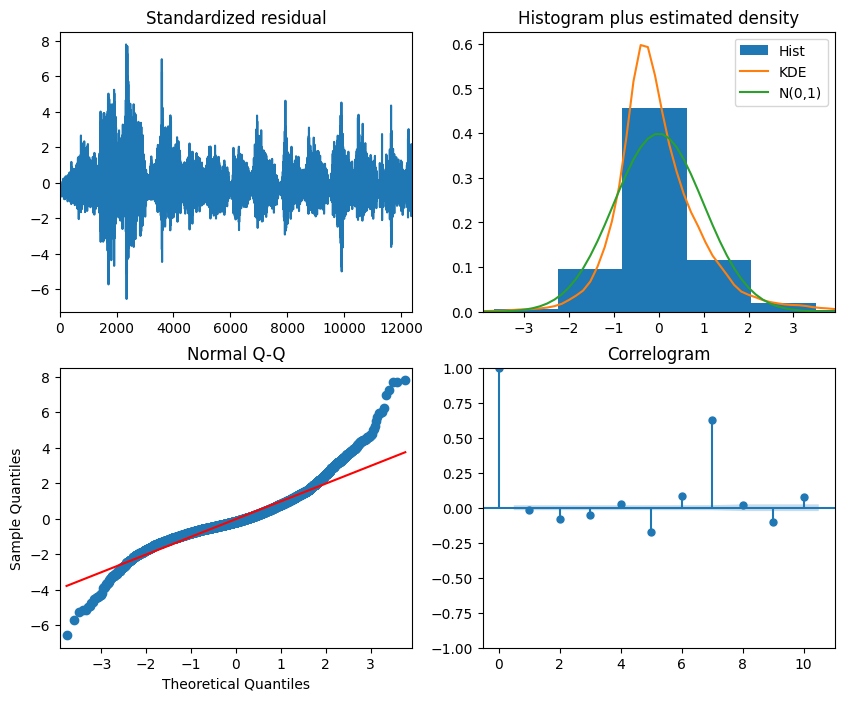

In [109]:
model.plot_diagnostics(figsize=(10, 8))
plt.show()

In [108]:
auto_forecast=auto_model.forecast(steps=len(test))
rmse_auto = rmse(test_truth["y"].values, auto_forecast)

AttributeError: 'ARIMA' object has no attribute 'forecast'

In [100]:
seasonal_period = 8  # døgnsesong

sarima_model = SARIMAX(
    train["y"],
    order=(2,0,2),              # ← ingen ordinær differensiering
    seasonal_order=(1,1,1,8),   # døgnsesong
    enforce_stationarity=False,
    enforce_invertibility=False
)


sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=len(test))

rmse_sarima = rmse(test_truth["y"].values, sarima_forecast)

print("SARIMA RMSE:", rmse_sarima)

SARIMA RMSE: 83.52067742294562


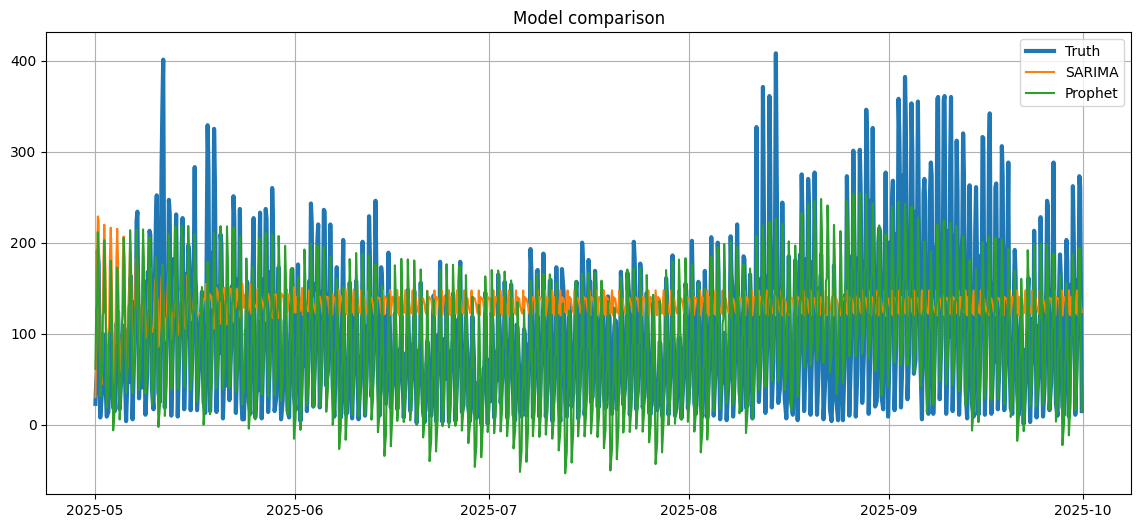

In [101]:
plt.figure(figsize=(14,6))

plt.plot(test["ds"], test_truth["y"], label="Truth", linewidth=3)
plt.plot(test["ds"], sarima_forecast, label="SARIMA")
plt.plot(test["ds"], model, label="auto_arima")
plt.plot(test["ds"], prophet_pred, label="Prophet")

plt.title("Model comparison")
plt.legend()
plt.grid(True)
plt.show()


In [102]:
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)


In [103]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train[["y"]])

window = 24  # 24 tidssteg tilbake

X_train, y_train = create_sequences(scaled_train, window)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

In [104]:
#model_lstm = Sequential([
#    LSTM(50, activation='tanh', input_shape=(window, 1)),
#    Dense(1)
#])

#model_lstm.compile(optimizer='adam', loss='mse')

#model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

In [105]:
#history = scaled_train[-window:].flatten().tolist()
#predictions = []

#for _ in range(len(test)):
#    x_input = np.array(history[-window:]).reshape((1, window, 1))
#    yhat = model_lstm.predict(x_input, verbose=0)
#    predictions.append(yhat[0,0])
#    history.append(yhat[0,0])

# Skaler tilbake
#lstm_pred = scaler.inverse_transform(np.array(predictions).reshape(-1,1)).flatten()

#rmse_lstm = rmse(test_truth["y"].values, lstm_pred)

#print("LSTM RMSE:", rmse_lstm)